## 1306. Jump Game III

Given an array of non-negative integers `arr`, you are initially positioned at `start` index of the array.
When you are at index `i`, you can jump to `i + arr[i]` or `i - arr[i]`.

Return `true` if you can reach **any** index with value `0`, otherwise return `false`.

Notice that you can not jump outside of the array at any time.

**Example 1:**
```
Input: arr = [4,2,3,0,3,1,2], start = 5
Output: true
Explanation: All possible ways to reach at index 3 with value 0:
  - index 5 → index 4 → index 1 → index 3
  - index 5 → index 6 → index 4 → index 1 → index 3
```

**Example 2:**
```
Input: arr = [4,2,3,0,3,1,2], start = 0
Output: true
Explanation: One possible way to reach at index 3 with value 0:
  - index 0 → index 4 → index 1 → index 3
```

**Example 3:**
```
Input: arr = [3,0,2,1,2], start = 2
Output: false
Explanation: There is no way to reach at index 1 with value 0.
```

**Constraints:**
- `1 <= arr.length <= 5 * 10^4`
- `0 <= arr[i] < arr.length`
- `0 <= start < arr.length`

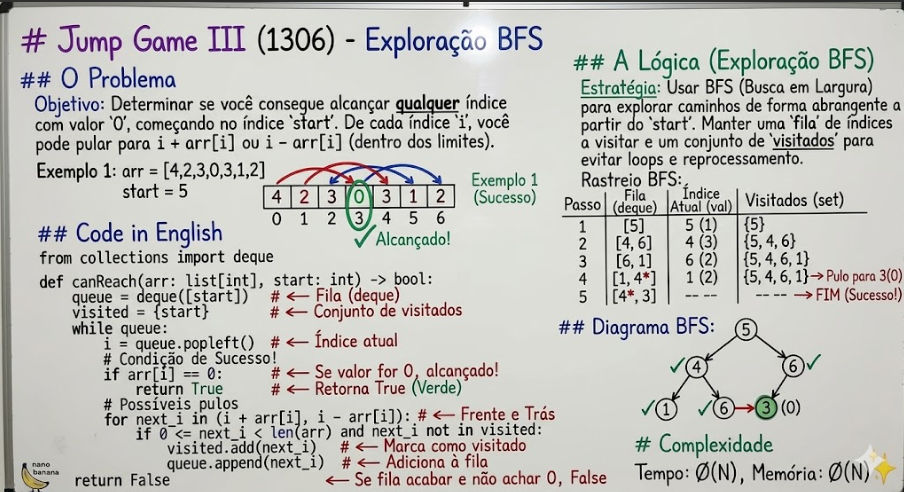

### Solução: BFS (Level by Level)

Diferente do Jump Game I e II, aqui os saltos podem ir para **frente e para trás** (`i + arr[i]` ou `i - arr[i]`).
Isso torna o problema um **grafo não-direcionado** — e BFS é a abordagem natural.

- Usamos um `visited` set para evitar ciclos infinitos
- Expandimos a partir do `start` explorando os dois vizinhos possíveis
- Retornamos `True` ao encontrar qualquer índice com `arr[i] == 0`

In [3]:
from collections import deque

def canReach(arr, start):
    """BFS: explora índices alcançáveis a partir de start, retorna True se achar arr[i]==0."""
    n = len(arr)
    visited = set()
    queue = deque([start])

    while queue:
        i = queue.popleft()

        if arr[i] == 0:
            return True

        if i in visited:
            continue
        visited.add(i)

        # Dois saltos possíveis: frente e trás
        for next_i in (i + arr[i], i - arr[i]):
            if 0 <= next_i < n and next_i not in visited:
                queue.append(next_i)

    return False

# Exemplos de teste
print(canReach([4,2,3,0,3,1,2], 5))  # True
print(canReach([4,2,3,0,3,1,2], 0))  # True
print(canReach([3,0,2,1,2], 2))      # False

True
True
False


### Solução alternativa: DFS recursivo

Mesma ideia, mas usando recursão com `visited` para evitar ciclos.

In [4]:
def canReachDFS(arr, start):
    """DFS recursivo com visited set para evitar ciclos."""
    n = len(arr)
    visited = set()

    def dfs(i):
        if i < 0 or i >= n or i in visited:
            return False
        if arr[i] == 0:
            return True
        visited.add(i)
        return dfs(i + arr[i]) or dfs(i - arr[i])

    return dfs(start)

# Exemplos de teste
print(canReachDFS([4,2,3,0,3,1,2], 5))  # True
print(canReachDFS([4,2,3,0,3,1,2], 0))  # True
print(canReachDFS([3,0,2,1,2], 2))      # False

True
True
False
